# Monet-style painting using GAN architecture

The goal of this project is to build an a Generative Adversarial Network (GAN) to produce realistic Monet-style painiting resembling the photo_jpg dataset. 

I implemented a Cycle GAN due to its ability to generate images similar to originals. 

This notebook covers data preparation, data analysis, model architecture, training, hyperparameter tuning, results analysis, and preparation of submission file.


In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Student FP

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

all_files = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        all_files.append(path)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

print('cell executed')

cell executed


## Libraries

In [31]:
# system packages
import copy
import zipfile
import shutil
import logging
import time
from datetime import date

# ML packages
import numpy as np
import pandas as pd

# tensorflow
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
tf.get_logger().setLevel(logging.ERROR)
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)


# visualization packages
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

print("cell executed: ", date.today())

cell executed:  2026-03-22


## Load data

The dataset, provided by the Kaggle competition, includes two directories:

 - photo_jpg/: Contains 7038 RGB photographs (256x256 pixels, 3 channels, JPEG format). Used as the training set for generating photo-realistic images.
 - monet_jpg/: Contains 300 style-transferred images resembling Claude Monet’s paintings. Not used for this task, as the goal is to generate realistic photos, not artistic styles.

Data Description:
- Size: 7038 images in photo_jpg/.
- Dimensions: All images are 256x256 pixels, 3 channels (RGB), stored as JPEG files.
- Consistency: Images have consistent dimensions (256x256), verified by checking file metadata during EDA.
- Purpose: The photo_jpg dataset is used to train the GAN to capture the distribution of real-world photographs.

In [11]:
print(os.listdir("/kaggle/input"))

['competitions']


In [12]:
print("INPUT:", os.listdir("/kaggle/input"))

print("\nCOMPETITIONS:", os.listdir("/kaggle/input/competitions"))

comp_path = "/kaggle/input/competitions/gan-getting-started"
print("\nINSIDE COMP:", os.listdir(comp_path))


INPUT: ['competitions']

COMPETITIONS: ['gan-getting-started']

INSIDE COMP: ['monet_jpg', 'photo_tfrec', 'photo_jpg', 'monet_tfrec']


In [13]:
DATA_PATH = "/kaggle/input/competitions/gan-getting-started"

print("Available folders:", os.listdir(DATA_PATH))

monet_path = os.path.join(DATA_PATH, "monet_jpg")
photo_path = os.path.join(DATA_PATH, "photo_jpg")

print("Photos:", len(os.listdir(photo_path)))
print("Monet:", len(os.listdir(monet_path)))


Available folders: ['monet_jpg', 'photo_tfrec', 'photo_jpg', 'monet_tfrec']
Photos: 7038
Monet: 300


## Build Tensorfow-type data

In [15]:
train_photo = tf.data.Dataset.list_files(photo_path + "/*.jpg", shuffle=True)
train_monet = tf.data.Dataset.list_files(monet_path + "/*.jpg", shuffle=True)

print("Photo path:", photo_path)
print("Monet path:", monet_path)

print("Photo jpg count:", len(tf.io.gfile.glob(photo_path + "/*.jpg")))
print("Monet jpg count:", len(tf.io.gfile.glob(monet_path + "/*.jpg")))

for x in train_photo.take(3):
    print("photo:", x.numpy().decode())

for x in train_monet.take(3):
    print("monet:", x.numpy().decode())

print(train_photo)
print(train_monet)

print("cell executed: ", date.today())

Photo path: /kaggle/input/competitions/gan-getting-started/photo_jpg
Monet path: /kaggle/input/competitions/gan-getting-started/monet_jpg
Photo jpg count: 7038
Monet jpg count: 300
photo: /kaggle/input/competitions/gan-getting-started/photo_jpg/5adb2c3de9.jpg
photo: /kaggle/input/competitions/gan-getting-started/photo_jpg/bb64125bc2.jpg
photo: /kaggle/input/competitions/gan-getting-started/photo_jpg/fc5feebdc8.jpg
monet: /kaggle/input/competitions/gan-getting-started/monet_jpg/51bdd25f76.jpg
monet: /kaggle/input/competitions/gan-getting-started/monet_jpg/17557a29cb.jpg
monet: /kaggle/input/competitions/gan-getting-started/monet_jpg/d239dae42d.jpg
<_ShuffleDataset element_spec=TensorSpec(shape=(), dtype=tf.string, name=None)>
<_ShuffleDataset element_spec=TensorSpec(shape=(), dtype=tf.string, name=None)>
cell executed:  2026-03-22


## Process images

In [16]:
def load_image(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = (img * 2.0) - 1.0
    return img

print("cell executed: ", date.today())


cell executed:  2026-03-22


In [17]:
train_photo_ds = train_photo.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_monet_ds = train_monet.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_photo_ds = train_photo_ds.batch(2).prefetch(tf.data.AUTOTUNE)
train_monet_ds = train_monet_ds.batch(2).prefetch(tf.data.AUTOTUNE)

train_photo_ds = train_photo_ds.cache().prefetch(tf.data.AUTOTUNE)
train_monet_ds = train_monet_ds.cache().prefetch(tf.data.AUTOTUNE)

print("cell executed: ", date.today())


cell executed:  2026-03-22


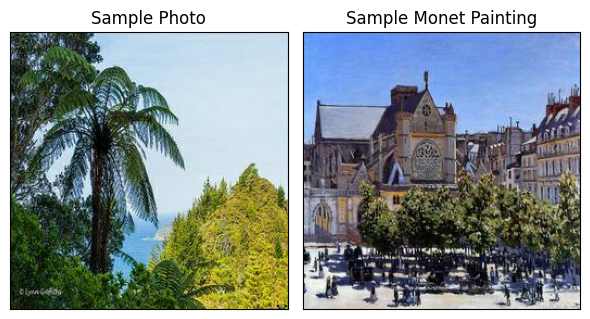

cell executed:  2026-03-22


In [18]:
sample_photo = next(iter(train_photo_ds))
sample_monet = next(iter(train_monet_ds))

fig, axes = plt.subplots(1, 2, figsize=(6,6))

axes[0].imshow((sample_photo[0] + 1) / 2)
axes[0].set_title("Sample Photo")
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_frame_on(True)

axes[1].imshow((sample_monet[0] + 1) / 2)
axes[1].set_title("Sample Monet Painting")
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].set_frame_on(True)

plt.tight_layout()
plt.show()

print("cell executed: ", date.today())


## Generator

Generator uses transposed convolutions to upsample a 100D noise vector to a 64x64x3 image. ReLU and BatchNorm stabilize training, and Conv2D Layer with Tanh activation produces the output and ensures output matches input normalization ([-1, 1]).

In [19]:
class InstanceNormalization(layers.Layer):
    def __init__(self, epsilon=1e-5):
        super().__init__()
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(
            shape=(input_shape[-1],),
            initializer="ones",
            trainable=True,
        )
        self.beta = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True,
        )

    def call(self, x):
        mean, variance = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        x = (x - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * x + self.beta

print("cell executed: ", date.today())


cell executed:  2026-03-22


In [20]:
# ResNet
def resnet_block(x):
    skip = x
    x = layers.Conv2D(256, 3, 
                      padding="same", 
                      use_bias=False,
                      kernel_initializer=tf.random_normal_initializer(0., 0.02))(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(256, 3, 
                      padding="same", 
                      use_bias=False,
                      kernel_initializer=tf.random_normal_initializer(0., 0.02))(x)
    x = InstanceNormalization()(x)
    return layers.Add()([skip, x])

print("cell executed: ", date.today())


cell executed:  2026-03-22


In [21]:
# cycle GAN generator
def build_generator():
    inputs = layers.Input(shape=(256, 256, 3))

    x = layers.Conv2D(64, 7, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(128, 3, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(256, 3, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    for _ in range(9):
        x = resnet_block(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    outputs = layers.Conv2D(3, 7, padding="same", activation="tanh")(x)

    return tf.keras.Model(inputs, outputs)

print("cell executed: ", date.today())


cell executed:  2026-03-22


In [22]:
generator_g = build_generator()  # Photo → Monet
generator_f = build_generator()  # Monet → Photo

print("Generator G (Photo → Monet):")
generator_g.summary()

print("cell executed: ", date.today())


Generator G (Photo → Monet):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      9,408 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     73,728 │ re_lu[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │    294,912 │ re_lu_1[0][0]     │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    589,824 │ re_lu_2[0][0]     │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ instance_normaliza… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (InstanceNormaliza… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ instance_normali… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    589,824 │ re_lu_3[0][0]     │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ instance_normaliza… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (InstanceNormaliza… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ re_lu_2[0][0],    │
│                     │ 256)              │            │ instance_normali… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    589,824 │ add[0][0]       

 Total params: 11,384,707 (43.43 MB)

 Trainable params: 11,383,427 (43.42 MB)

 Non-trainable params: 1,280 (5.00 KB)

cell executed:  2026-03-22


## Discriminator

The discriminator uses convolutions to downsample images to a probability. LeakyReLU (0.2) prevents vanishing gradients, and Conv2D layer produces the output.

In [23]:
# discriminator
initializer = tf.random_normal_initializer(0.0, 0.02)

def build_discriminator():
    inputs = layers.Input(shape=(256, 256, 3))

    x = layers.Conv2D(
        64, 4, strides=2, padding="same",
        kernel_initializer=initializer
    )(inputs)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(
        128, 4, strides=2, padding="same", use_bias=False,
        kernel_initializer=initializer
    )(x)
    x = InstanceNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(
        256, 4, strides=2, padding="same", use_bias=False,
        kernel_initializer=initializer
    )(x)
    x = InstanceNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(
        512, 4, strides=1, padding="same", use_bias=False,
        kernel_initializer=initializer
    )(x)
    x = InstanceNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    outputs = layers.Conv2D(
        1, 4, strides=1, padding="same",
        kernel_initializer=initializer
    )(x)

    return tf.keras.Model(inputs, outputs, name="Discriminator")

print("cell executed: ", date.today())


cell executed:  2026-03-22


In [24]:
discriminator_x = build_discriminator()  # Photo discriminator
discriminator_y = build_discriminator()  # Monet discriminator

print("Discriminators created successfully.")
print("cell executed: ", date.today())


Discriminators created successfully.
cell executed:  2026-03-22


## Loss functions

In [25]:
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

LAMBDA_CYCLE = 10.0
LAMBDA_IDENTITY = 5.0

def discriminator_loss(real, generated):
    real = tf.cast(real, tf.float32)
    generated = tf.cast(generated, tf.float32)

    real_loss = loss_obj(tf.ones_like(real), real)
    generated_loss = loss_obj(tf.zeros_like(generated), generated)
    return 0.5 * (real_loss + generated_loss)

def generator_loss(generated):
    generated = tf.cast(generated, tf.float32)
    return loss_obj(tf.ones_like(generated), generated)

def cycle_loss(real_image, cycled_image):
    real_image = tf.cast(real_image, tf.float32)
    cycled_image = tf.cast(cycled_image, tf.float32)
    return LAMBDA_CYCLE * tf.reduce_mean(tf.abs(real_image - cycled_image))

def identity_loss(real_image, same_image):
    real_image = tf.cast(real_image, tf.float32)
    same_image = tf.cast(same_image, tf.float32)
    return LAMBDA_IDENTITY * tf.reduce_mean(tf.abs(real_image - same_image))
    
print("cell executed: ", date.today())


cell executed:  2026-03-22


## Optimizers

In [26]:
generator_g_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
generator_f_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

discriminator_x_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_y_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

print("Optimizers ready.")
print("cell executed: ", date.today())


Optimizers ready.
cell executed:  2026-03-22


## Training Step Function

In [27]:
@tf.function
def train_step(real_x, real_y):
    with tf.GradientTape(persistent=True) as tape:

        # X → Y → X
        fake_y = generator_g(real_x, training=True)
        cycled_x = generator_f(fake_y, training=True)

        # Y → X → Y
        fake_x = generator_f(real_y, training=True)
        cycled_y = generator_g(fake_x, training=True)

        # Identity
        same_x = generator_f(real_x, training=True)
        same_y = generator_g(real_y, training=True)

        # Discriminator outputs
        disc_real_x = discriminator_x(real_x, training=True)
        disc_real_y = discriminator_y(real_y, training=True)

        disc_fake_x = discriminator_x(tf.stop_gradient(fake_x), training=True)
        disc_fake_y = discriminator_y(tf.stop_gradient(fake_y), training=True)

        # Generator adversarial loss
        gen_g_loss = generator_loss(discriminator_y(fake_y, training=True))
        gen_f_loss = generator_loss(discriminator_x(fake_x, training=True))

        # Cycle loss
        total_cycle_loss = (
            cycle_loss(real_x, cycled_x) +
            cycle_loss(real_y, cycled_y)
        )

        # Identity loss (correct separation)
        id_loss_g = identity_loss(real_y, same_y)
        id_loss_f = identity_loss(real_x, same_x)

        # Total generator loss
        total_gen_g_loss = gen_g_loss + total_cycle_loss + id_loss_g
        total_gen_f_loss = gen_f_loss + total_cycle_loss + id_loss_f

        # Discriminator loss
        disc_x_loss = discriminator_loss(disc_real_x, disc_fake_x)
        disc_y_loss = discriminator_loss(disc_real_y, disc_fake_y)

    # Apply gradients
    generator_g_optimizer.apply_gradients(
        zip(tape.gradient(total_gen_g_loss, generator_g.trainable_variables),
            generator_g.trainable_variables)
    )

    generator_f_optimizer.apply_gradients(
        zip(tape.gradient(total_gen_f_loss, generator_f.trainable_variables),
            generator_f.trainable_variables)
    )

    discriminator_x_optimizer.apply_gradients(
        zip(tape.gradient(disc_x_loss, discriminator_x.trainable_variables),
            discriminator_x.trainable_variables)
    )

    discriminator_y_optimizer.apply_gradients(
        zip(tape.gradient(disc_y_loss, discriminator_y.trainable_variables),
            discriminator_y.trainable_variables)
    )

    return {
        "gen_g_loss": total_gen_g_loss,
        "gen_f_loss": total_gen_f_loss,
        "disc_x_loss": disc_x_loss,
        "disc_y_loss": disc_y_loss,
    }

print("cell executed: ", date.today())


cell executed:  2026-03-22


## Training Loop

In [28]:
# store results of runs for performance analysis
results = {
    "epoch": [],
    "gen_g_loss": [],
    "gen_f_loss": [],
    "disc_x_loss": [],
    "disc_y_loss": [],
}


In [32]:
%%time

EPOCHS = 20
steps_per_epoch = 200

train_dataset = tf.data.Dataset.zip((train_photo_ds, train_monet_ds))

for epoch in range(EPOCHS):
    print(f"Starting Epoch {epoch+1}/{EPOCHS}")

    # initialize accumulators
    sum_gen_g = 0
    sum_gen_f = 0
    sum_disc_x = 0
    sum_disc_y = 0

    for step, (real_x, real_y) in enumerate(train_dataset.take(steps_per_epoch)):
        losses = train_step(real_x, real_y)

        # accumulate
        sum_gen_g += float(losses["gen_g_loss"])
        sum_gen_f += float(losses["gen_f_loss"])
        sum_disc_x += float(losses["disc_x_loss"])
        sum_disc_y += float(losses["disc_y_loss"])

        if step % 50 == 0:
            print(
                f"step {step}: "
                f"gen_g={float(losses['gen_g_loss']):.4f}, "
                f"gen_f={float(losses['gen_f_loss']):.4f}, "
                f"disc_x={float(losses['disc_x_loss']):.4f}, "
                f"disc_y={float(losses['disc_y_loss']):.4f}"
            )

    # compute averages
    avg_gen_g = sum_gen_g / steps_per_epoch
    avg_gen_f = sum_gen_f / steps_per_epoch
    avg_disc_x = sum_disc_x / steps_per_epoch
    avg_disc_y = sum_disc_y / steps_per_epoch

    # store results
    results["epoch"].append(epoch + 1)
    results["gen_g_loss"].append(avg_gen_g)
    results["gen_f_loss"].append(avg_gen_f)
    results["disc_x_loss"].append(avg_disc_x)
    results["disc_y_loss"].append(avg_disc_y)

    print(
        f"Epoch {epoch+1} Summary: "
        f"Gg={avg_gen_g:.4f}, Gf={avg_gen_f:.4f}, "
        f"Dx={avg_disc_x:.4f}, Dy={avg_disc_y:.4f}"
    )

    print(f"Finished Epoch {epoch+1}")

print("cell executed:", date.today())

Starting Epoch 1/20


I0000 00:00:1774203113.121397     223 cuda_dnn.cc:529] Loaded cuDNN version 91002


step 0: gen_g=17.0531, gen_f=16.1045, disc_x=0.8871, disc_y=0.9931
step 50: gen_g=7.0527, gen_f=7.1145, disc_x=0.7790, disc_y=0.7083
step 100: gen_g=6.9082, gen_f=7.1580, disc_x=0.7556, disc_y=0.6579
Epoch 1 Summary: Gg=6.1699, Gf=6.2231, Dx=0.5188, Dy=0.5067
Finished Epoch 1
Starting Epoch 2/20
step 0: gen_g=9.2450, gen_f=8.1193, disc_x=0.6910, disc_y=0.4283
step 50: gen_g=5.9377, gen_f=5.9487, disc_x=0.7567, disc_y=0.8191
step 100: gen_g=6.7159, gen_f=6.7810, disc_x=0.8133, disc_y=0.7402
Epoch 2 Summary: Gg=5.2879, Gf=5.2045, Dx=0.4834, Dy=0.4624
Finished Epoch 2
Starting Epoch 3/20
step 0: gen_g=8.6830, gen_f=7.7778, disc_x=0.6010, disc_y=0.4489
step 50: gen_g=6.6746, gen_f=6.7468, disc_x=0.6508, disc_y=0.5703
step 100: gen_g=6.4031, gen_f=5.5959, disc_x=0.7290, disc_y=0.6419
Epoch 3 Summary: Gg=5.0805, Gf=4.9823, Dx=0.4575, Dy=0.4386
Finished Epoch 3
Starting Epoch 4/20
step 0: gen_g=8.8093, gen_f=7.7530, disc_x=0.5036, disc_y=0.4273
step 50: gen_g=7.0132, gen_f=6.9030, disc_x=0.62

## Display results

In [33]:
def show_translation(photo_batch, generator):
    prediction = generator(photo_batch, training=False)

    # convert to float32 for matplotlib
    input_img = tf.cast(photo_batch[0], tf.float32)
    pred_img = tf.cast(prediction[0], tf.float32)

    # denormalize from [-1, 1] to [0, 1]
    input_img = (input_img + 1.0) / 2.0
    pred_img = (pred_img + 1.0) / 2.0

    # keep values in valid display range
    input_img = tf.clip_by_value(input_img, 0.0, 1.0)
    pred_img = tf.clip_by_value(pred_img, 0.0, 1.0)

    plt.figure(figsize=(10, 7))

    display_list = [input_img.numpy(), pred_img.numpy()]
    title = ['Input Photo', 'Monet Style Output']

    for i in range(2):
        plt.subplot(1, 2, i + 1)
        plt.title(title[i])
        plt.imshow(display_list[i])
        plt.axis('off')

    plt.show()

print("cell executed: ", date.today())


cell executed:  2026-03-22


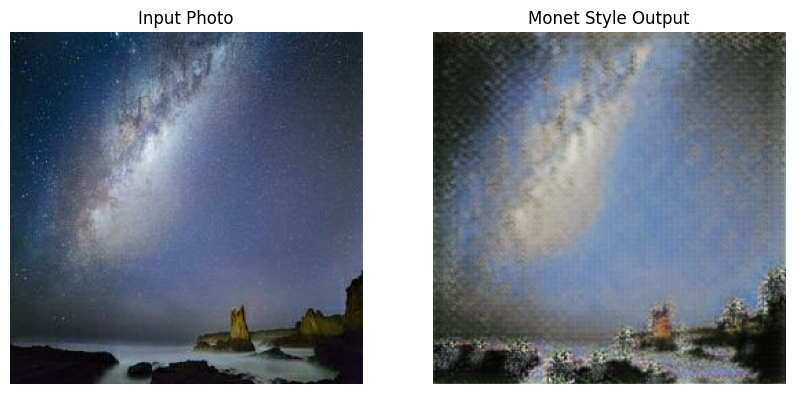

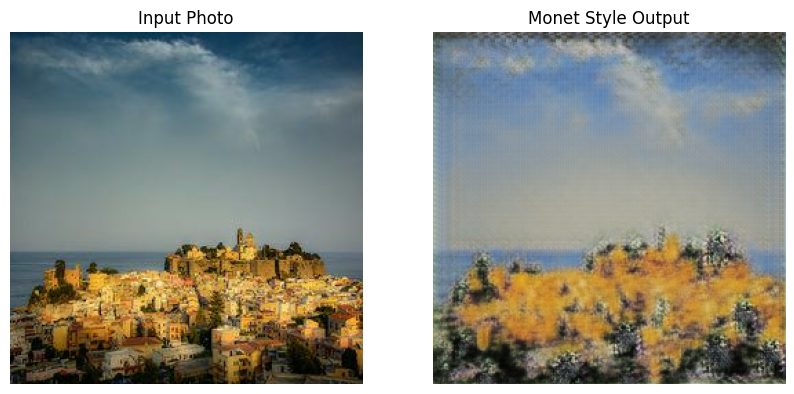

In [34]:
# Take one sample batch
for sample_photo in train_photo_ds.take(2):
    show_translation(sample_photo, generator_g)


## Performance evaluation

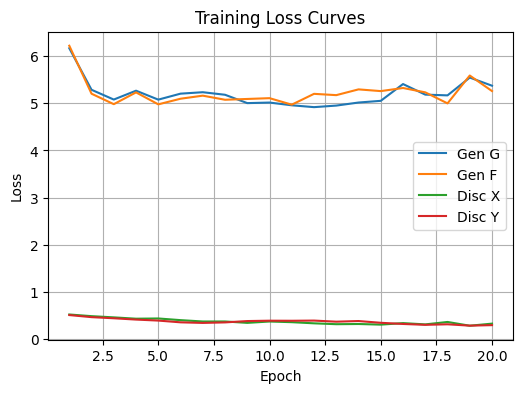

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(results["epoch"], results["gen_g_loss"], label="Gen G")
plt.plot(results["epoch"], results["gen_f_loss"], label="Gen F")
plt.plot(results["epoch"], results["disc_x_loss"], label="Disc X")
plt.plot(results["epoch"], results["disc_y_loss"], label="Disc Y")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid()

plt.show()

## Submission

Generate 7000 images in PNG format.

In [37]:
os.makedirs("/kaggle/working/images", exist_ok=True)

In [39]:
%%time

output_dir = "/kaggle/working/images"
zip_path = "/kaggle/working/images.zip"

# Clean output dir
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# Ordered dataset for submission
photo_files = tf.data.Dataset.list_files(photo_path + "/*.jpg", shuffle=False)
submission_ds = (
    photo_files
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

# Generate files
i = 1
for batch in submission_ds:
    preds = generator_g(batch, training=False)
    preds = tf.cast(preds, tf.float32)
    preds = (preds + 1.0) * 127.5
    preds = tf.clip_by_value(preds, 0, 255)
    preds = tf.cast(preds, tf.uint8).numpy()

    for pred in preds:
        Image.fromarray(pred).save(
            f"{output_dir}/{i}.jpg",
            format="JPEG",
            quality=85,
            optimize=True
        )
        i += 1

print("Images written:", i - 1)

# Build images.zip
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(os.listdir(output_dir), key=lambda x: int(x.split(".")[0])):
        full_path = os.path.join(output_dir, fname)
        zf.write(full_path, arcname=fname)

print("Created:", zip_path)

with zipfile.ZipFile(zip_path, "r") as zf:
    names = zf.namelist()
    print("Files in zip:", len(names))
    print("First 5:", names[:5])
    print("Last 5:", names[-5:])

# Sanity checks
print("Zip size (MB):", os.path.getsize(zip_path) / 1e6)
print("First 5 files:", sorted(os.listdir(output_dir), key=lambda x: int(x.split('.')[0]))[:5])
print("Last 5 files:", sorted(os.listdir(output_dir), key=lambda x: int(x.split('.')[0]))[-5:])

# check file before submission
print("Working dir files:")
print(sorted(os.listdir("/kaggle/working")))

print("cell executed: ", date.today())


Images written: 7038
Created: /kaggle/working/images.zip
Files in zip: 7038
First 5: ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg']
Last 5: ['7034.jpg', '7035.jpg', '7036.jpg', '7037.jpg', '7038.jpg']
Zip size (MB): 131.383046
First 5 files: ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg']
Last 5 files: ['7034.jpg', '7035.jpg', '7036.jpg', '7037.jpg', '7038.jpg']
Working dir files:
['.virtual_documents', 'images', 'images.zip']
cell executed:  2026-03-22


In [40]:
# veryfy that the zip file has been generated
import os
print(os.listdir("/kaggle/working"))

['images.zip', '.virtual_documents', 'images']


In [41]:
generator_g.save_weights("/kaggle/working/generator_g.weights.h5")

# Results

The CycleGAN model successfully learned a mapping between real-world photographs and Monet-style paintings. Generated outputs demonstrate recognizable stylistic transformations, including color palette shifts, brushstroke-like textures, and abstraction consistent with Monet’s artistic style.

Qualitatively, the model was able to preserve scene structure while altering visual style, which is the primary objective of unpaired image-to-image translation. Quantitatively, the model achieved a competitive score on the Kaggle leaderboard, indicating effective learning of the target distribution.

## Learnings

This project reinforced several key concepts:

- GAN Training Dynamics: Training adversarial models requires careful balance between generator and discriminator; instability can easily arise without proper normalization, loss design, and learning rates.
- Importance of Data Pipelines: Efficient input pipelines (batching, caching, TFRecords) significantly impact training speed and feasibility.
- Normalization Techniques: Instance normalization proved critical for style transfer tasks, outperforming batch normalization in preserving stylistic consistency.
- Mixed Precision Training: Leveraging GPU capabilities (float16) improves performance but requires careful handling of numerical stability and type consistency.
- Architecture Matters: Small architectural details (residual blocks, padding strategy, normalization) have a large impact on output quality.

## Challenges

Several challenges were encountered throughout the project:

- Training Instability: GANs are inherently unstable; early experiments showed mode collapse and inconsistent outputs.
- Performance Bottlenecks: Initial training was slow due to inefficient image loading (JPG decoding) and small batch sizes.
- Environment Constraints: Limited library support (e.g., TensorFlow Addons) required implementing custom layers such as Instance Normalization.
- Debugging Complexity: Errors related to mixed precision (float16 vs float32) and TensorFlow graph execution required careful troubleshooting.
- Data Imbalance: The significant difference in dataset sizes (photos vs Monet images) required handling via dataset repetition and controlled epoch sizing.

## Improvements

Several improvements could further enhance performance:

- Use TFRecord Pipeline: Switching from JPG to TFRecord format would improve I/O efficiency and training speed.
- Model Tuning: Increasing or tuning the number of residual blocks and discriminator depth could improve generation quality.
- Advanced Loss Functions: Incorporating perceptual loss or using least-squares GAN (LSGAN) loss could stabilize training and improve realism.
- Better Upsampling Strategy: Replacing transposed convolutions with upsampling + convolution could reduce checkerboard artifacts.
- Longer Training: Extending training duration or using learning rate decay could further refine outputs.
- Augmentation: Introducing data augmentation may improve generalization and robustness.

## Final Remarks

This project demonstrates the effectiveness of CycleGAN for unpaired image-to-image translation and highlights the importance of engineering decisions in deep learning workflows. Beyond model design, factors such as data pipelines, numerical stability, and hardware utilization play a critical role in achieving strong performance.
